In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
df=pd.read_csv("Titanic-Dataset.csv")

In [40]:
df.drop(["PassengerId","Name","Ticket","Cabin"],axis=1,inplace=True)

In [41]:
df["Age"].fillna(df["Age"].median(),inplace=True)

C:\Users\Adrija\AppData\Local\Temp\ipykernel_15048\860536840.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)


In [42]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\Adrija\AppData\Local\Temp\ipykernel_15048\122844256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [43]:
df["FamilySize"]=df["SibSp"]+df["Parch"]

In [44]:
df.drop(["SibSp","Parch"],axis=1,inplace=True)

In [45]:
df["Sex"]=df["Sex"].map({"male":0,"female":1})
df["Embarked"]=df["Embarked"].astype("category").cat.codes

In [46]:
df["Sex"].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [47]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,0,22.0,7.2500,2,1
1,1,1,1,38.0,71.2833,0,1
2,1,3,1,26.0,7.9250,2,0
3,1,1,1,35.0,53.1000,2,1
4,0,3,0,35.0,8.0500,2,0
...,...,...,...,...,...,...,...
886,0,2,0,27.0,13.0000,2,0
887,1,1,1,19.0,30.0000,2,0
888,0,3,1,28.0,23.4500,2,3
889,1,1,0,26.0,30.0000,0,0


In [48]:
x=df.drop("Survived",axis=1)
y=df["Survived"]

In [53]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [54]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 80.44692737430168 %
[[90 15]
 [20 54]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [66]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
from sklearn.metrics import accuracy_score
print("RF Accuracy:", accuracy_score(y_test, rf_pred)*100,"%")

RF Accuracy: 81.56424581005587 %


Text(0.5, 1.0, 'Feature Importance')

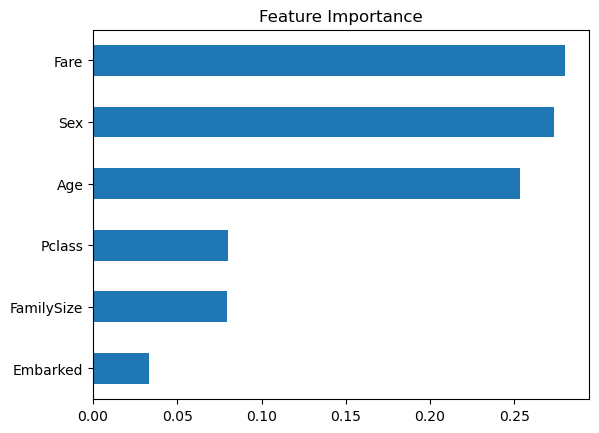

In [64]:
importance = pd.Series(rf.feature_importances_, index=x.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")

In [65]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,x,y, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.7890276818780994
